### Data Exploration of AqSolDB and AqSolDB Curated

In [1]:
"""Importing all required libraries """""
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import Descriptors

### Data Loading and Filtering

In [ ]:
# 1. Load and clean AqSolDB
df_aqsoldb = pd.read_csv('path/to/AqSolDB')
df_aqsoldb = df_aqsoldb.dropna(subset=["SMILES", "Solubility"]) # Dropping any molecules NaN (missing) values for SMILES or solubility
df_aqsoldb = df_aqsoldb.drop_duplicates(subset=['SMILES']) # Dropping any duplicate molecules

# 2. Load and clean AqSolDBc
df_aqsoldbc = pd.read_csv('path/to/AqSolDBc')
df_aqsoldbc = df_aqsoldbc.dropna(subset=["SMILES", "ExperimentalLogS"]) # Dropping any molecules NaN (missing) values for SMILES or solubility
df_aqsoldbc = df_aqsoldbc.drop_duplicates(subset=['SMILES']) # Dropping any duplicate molecules


#Calculating MW and LogP and adding them to the dataframe for each molecule and dropping any NaN values
df_aqsoldbc['MolWt'] = df_aqsoldbc['SMILES'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else np.nan)
df_aqsoldbc['MolLogP'] = df_aqsoldbc['SMILES'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else np.nan)
df_aqsoldbc = df_aqsoldbc.dropna(subset=['MolWt', 'MolLogP'])

[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:08] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not removing hydrogen atom without neighbors
[09:32:09] WARNING: not r

### Defining the Plotting Function

In [ ]:
def plot_distribution(y, xlabel, color, normal_overlay=False):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 5))
    
    # Base histogram (normalised) 
    sns.histplot(y, kde=False, stat='density', bins=30, color=color, alpha=0.6)
    
    mean = np.mean(y)
    median = np.median(y)
    std = np.std(y)
    n = len(y)
    
    # Normal distribution overlay logic - Color set to match the histogram
    if normal_overlay:
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean, std)
        plt.plot(x, p, color=color, linewidth=2, label='Normal Distribution')

    # Add vertical lines for mean and median
    plt.axvline(mean, color='black', linestyle='--', linewidth=1.2, label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='green', linestyle=':', linewidth=1.2, label=f"Median = {median:.2f}")

    # Set specific labels
    plt.xlabel(xlabel)
    plt.ylabel('Normalised frequency')

    # Annotate with text box 
    textstr = '\n'.join((
        f'n = {n}',
        f'Mean = {mean:.3f}',
        f'Median = {median:.3f}',
        f'SD = {std:.3f}'
    ))

    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.98, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.legend()
    plt.show()
    
    # Print output below the cell
    print(f"Mean: {mean:.3f}")
    print(f"Standard Deviation: {std:.3f}")

### Plotting Outputs

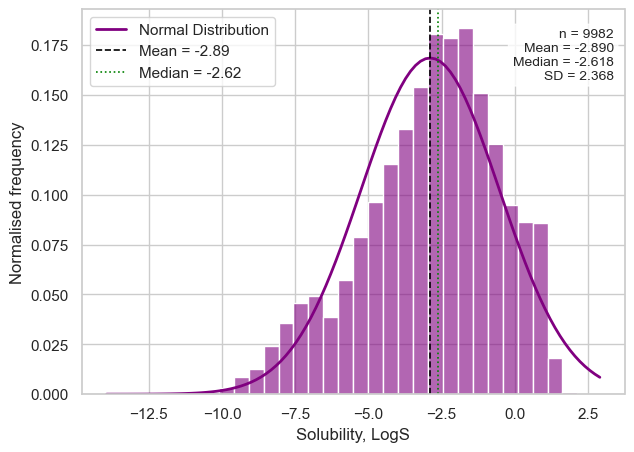

Mean: -2.890
Standard Deviation: 2.368


In [8]:
#AqSolDB solubility plot
plot_distribution(df_aqsoldb['Solubility'], 'Solubility, LogS', 'purple', normal_overlay=True) #Calling the function and setting the parameters

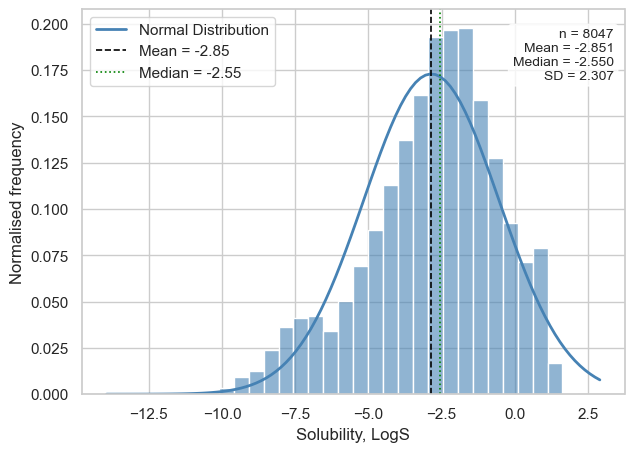

Mean: -2.851
Standard Deviation: 2.307


In [9]:
#AqSolDB curated solubility plot
plot_distribution(df_aqsoldbc['ExperimentalLogS'], 'Solubility, LogS', 'steelblue', normal_overlay=True)

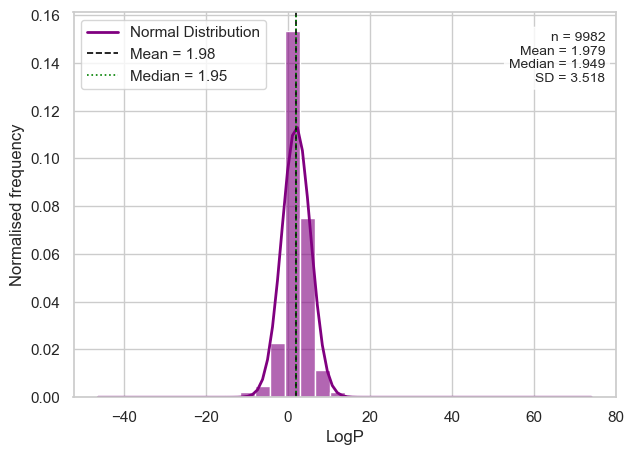

Mean: 1.979
Standard Deviation: 3.518


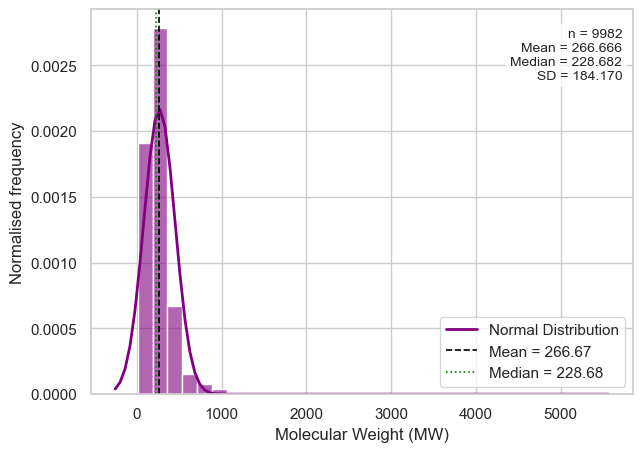

Mean: 266.666
Standard Deviation: 184.170


In [10]:
#AqSolDB LogP and MW plots
plot_distribution(df_aqsoldb['MolLogP'], 'LogP', 'purple', normal_overlay=True)
plot_distribution(df_aqsoldb['MolWt'], 'Molecular Weight (MW)', 'purple', normal_overlay=True)

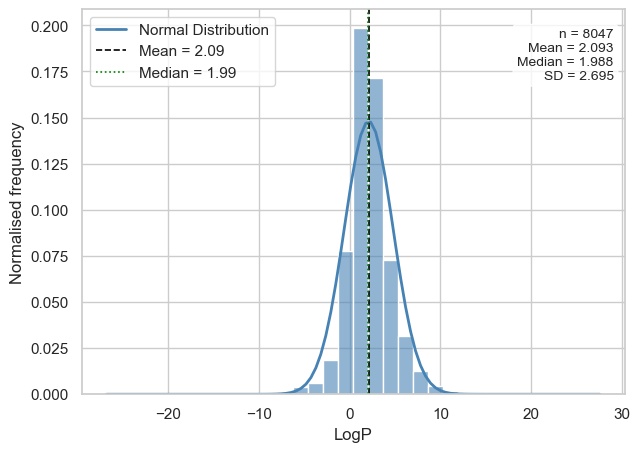

Mean: 2.093
Standard Deviation: 2.695


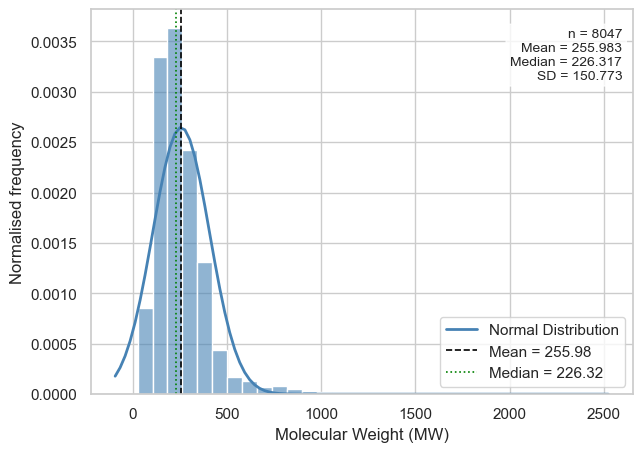

Mean: 255.983
Standard Deviation: 150.773


In [11]:
#AqSolDB curated LogP and MW plots
plot_distribution(df_aqsoldbc['MolLogP'], 'LogP', 'steelblue', normal_overlay=True)
plot_distribution(df_aqsoldbc['MolWt'], 'Molecular Weight (MW)', 'steelblue', normal_overlay=True)

### Test/Train Plots

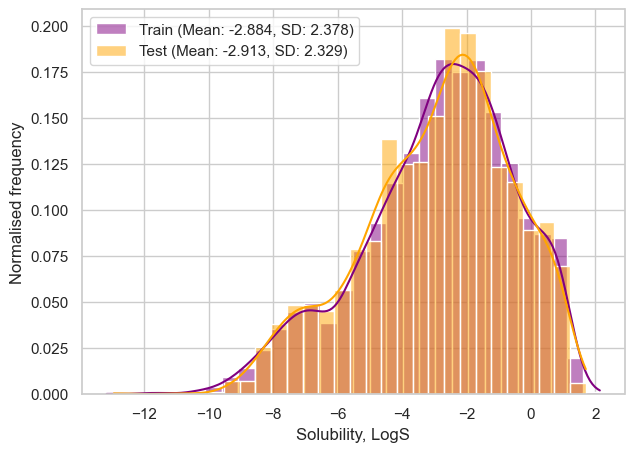

--- AqSolDB Train/Test Split Stats ---
Train - Mean: -2.884, SD: 2.378
Test  - Mean: -2.913, SD: 2.329


In [12]:
#Train/Test Overlay plot for AqSolDB
# 1. Setup Data
X_aq = df_aqsoldb['SMILES']
y_aq = df_aqsoldb['Solubility']

# Perform Train/Test Split
X_train_aq, X_test_aq, y_train_aq, y_test_aq = train_test_split(X_aq, y_aq, test_size=0.2, random_state=42)

# 2. Overlay plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Create labels with stats for the legend
train_label_aq = f"Train (Mean: {np.mean(y_train_aq):.3f}, SD: {np.std(y_train_aq):.3f})"
test_label_aq = f"Test (Mean: {np.mean(y_test_aq):.3f}, SD: {np.std(y_test_aq):.3f})"

# Plot train and test densities 
sns.histplot(y_train_aq, kde=True, stat='density', bins=30, color='purple', alpha=0.5, label=train_label_aq)
sns.histplot(y_test_aq, kde=True, stat='density', bins=30, color='orange', alpha=0.5, label=test_label_aq)

plt.xlabel('Solubility, LogS')
plt.ylabel('Normalised frequency')
plt.legend()
plt.show()

# 3. Print stats below the cell
print("--- AqSolDB Train/Test Split Stats ---")
print(f"Train - Mean: {np.mean(y_train_aq):.3f}, SD: {np.std(y_train_aq):.3f}")
print(f"Test  - Mean: {np.mean(y_test_aq):.3f}, SD: {np.std(y_test_aq):.3f}")

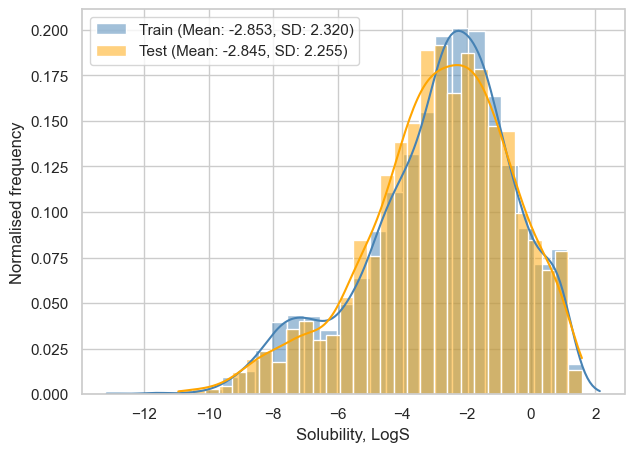

--- AqSolDBc Train/Test Split Stats ---
Train - Mean: -2.853, SD: 2.320
Test  - Mean: -2.845, SD: 2.255


In [13]:
#Train/Test Overlay plot for AqSolDBc
# 1. Setup Data 
X_aqc = df_aqsoldbc['SMILES']
y_aqc = df_aqsoldbc['ExperimentalLogS']

# Perform Train/Test Split
X_train_aqc, X_test_aqc, y_train_aqc, y_test_aqc = train_test_split(X_aqc, y_aqc, test_size=0.2, random_state=42)

# 2. Overlay plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Create labels with stats for the legend
train_label_aqc = f"Train (Mean: {np.mean(y_train_aqc):.3f}, SD: {np.std(y_train_aqc):.3f})"
test_label_aqc = f"Test (Mean: {np.mean(y_test_aqc):.3f}, SD: {np.std(y_test_aqc):.3f})"

# Plot train and test densities 
sns.histplot(y_train_aqc, kde=True, stat='density', bins=30, color='steelblue', alpha=0.5, label=train_label_aqc)
sns.histplot(y_test_aqc, kde=True, stat='density', bins=30, color='orange', alpha=0.5, label=test_label_aqc)

plt.xlabel('Solubility, LogS')
plt.ylabel('Normalised frequency')
plt.legend()
plt.show()

# 3. Print stats below the cell
print("--- AqSolDBc Train/Test Split Stats ---")
print(f"Train - Mean: {np.mean(y_train_aqc):.3f}, SD: {np.std(y_train_aqc):.3f}")
print(f"Test  - Mean: {np.mean(y_test_aqc):.3f}, SD: {np.std(y_test_aqc):.3f}")